In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Chargement des données préparées
accidents = pd.read_csv("../data/processed/accidents_prepares.csv")
usagers = pd.read_csv("../data/processed/usagers_prepares.csv")

In [3]:
print("Dataset accidents :")
print(accidents.shape)

print("\nDataset usagers :")
print(usagers.shape)

display(accidents.head())

display(usagers.head())

Dataset accidents :
(54402, 12)

Dataset usagers :
(125187, 20)


,Num_Acc,jour,mois,hrmn,lum,agg,atm,catr,lum_label,atm_label,agg_label,catr_label
0,202400000001,25,3,07:40,2,1,5,3,Crépuscule ou aube,Brouillard ou fumée,Hors agglomération,Route départementale
1,202400000002,20,3,15:05,1,2,7,4,Plein jour,Temps éblouissant,En agglomération,Voie communale
2,202400000003,22,3,19:30,2,1,1,4,Crépuscule ou aube,Normale,Hors agglomération,Voie communale
3,202400000004,24,3,17:50,1,2,7,4,Plein jour,Temps éblouissant,En agglomération,Voie communale
4,202400000005,25,3,19:35,5,1,2,1,Nuit avec éclairage public allumé,Pluie légère,Hors agglomération,Autoroute


,Num_Acc,grav,sexe,an_nais,catu,age,jour,mois,hrmn,lum,agg,atm,catr,lum_label,atm_label,agg_label,catr_label,grav_label,sexe_label,catu_label
0,202400000001,3,1,2003.0,1,21.0,25,3,07:40,2,1,5,3,Crépuscule ou aube,Brouillard ou fumée,Hors agglomération,Route départementale,Blessé hospitalisé,Masculin,Conducteur
1,202400000001,1,1,1997.0,1,27.0,25,3,07:40,2,1,5,3,Crépuscule ou aube,Brouillard ou fumée,Hors agglomération,Route départementale,Indemne,Masculin,Conducteur
2,202400000002,3,2,1927.0,3,97.0,20,3,15:05,1,2,7,4,Plein jour,Temps éblouissant,En agglomération,Voie communale,Blessé hospitalisé,Féminin,Piéton
3,202400000002,1,1,1987.0,1,37.0,20,3,15:05,1,2,7,4,Plein jour,Temps éblouissant,En agglomération,Voie communale,Indemne,Masculin,Conducteur
4,202400000003,4,2,2007.0,2,17.0,22,3,19:30,2,1,1,4,Crépuscule ou aube,Normale,Hors agglomération,Voie communale,Blessé léger,Féminin,Passager


# Analyse des données

Ce notebook présente une analyse des accidents de la route en France en 2024 à partir des données préparées.

## Répartition des accidents au cours de l'année

Nous commençons par analyser la répartition du nombre d'accidents selon les mois de l'année 2024.

In [4]:
# Nombre d'accidents par mois
accidents_par_mois = accidents["mois"].value_counts().sort_index()

print(accidents_par_mois)

mois
1     4069
2     3792
3     4370
4     4586
5     4517
6     5135
7     5209
8     4450
9     4620
10    4803
11    4477
12    4374
Name: count, dtype: int64


### Visualisation

Le graphique suivant permet de visualiser plus facilement l'évolution du nombre d'accidents au cours de l'année.

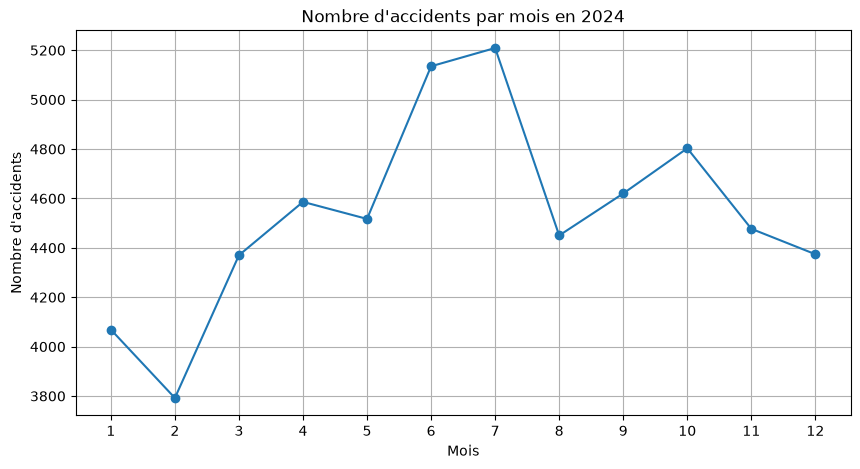

In [5]:
# Graphique du nombre d'accidents par mois

plt.figure(figsize=(10, 5))

plt.plot(
    accidents_par_mois.index,
    accidents_par_mois.values,
    marker="o"
)

plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")
plt.title("Nombre d'accidents par mois en 2024")

plt.xticks(range(1, 13))

plt.grid()

plt.show()

### Interprétation

Le nombre d'accidents varie selon les mois de l'année. Le mois de juillet présente le nombre d'accidents le plus élevé, avec 5 209 accidents, tandis que février est le mois où le nombre d'accidents est le plus faible, avec 3 792 accidents.

On observe également un nombre d'accidents relativement élevé pendant les mois de juin et juillet.

## Accidents selon les conditions de luminosité

Nous analysons maintenant la répartition des accidents selon les conditions de luminosité au moment de l'accident.

In [6]:
# Nombre d'accidents selon les conditions de luminosité

accidents_par_luminosite = (
    accidents["lum_label"]
    .value_counts()
)

print(accidents_par_luminosite)

lum_label
Plein jour                               35580
Nuit avec éclairage public allumé         8499
Nuit sans éclairage public                6101
Crépuscule ou aube                        3599
Nuit avec éclairage public non allumé      623
Name: count, dtype: int64


### Visualisation

Le graphique suivant permet de comparer le nombre d'accidents selon les différentes conditions de luminosité.

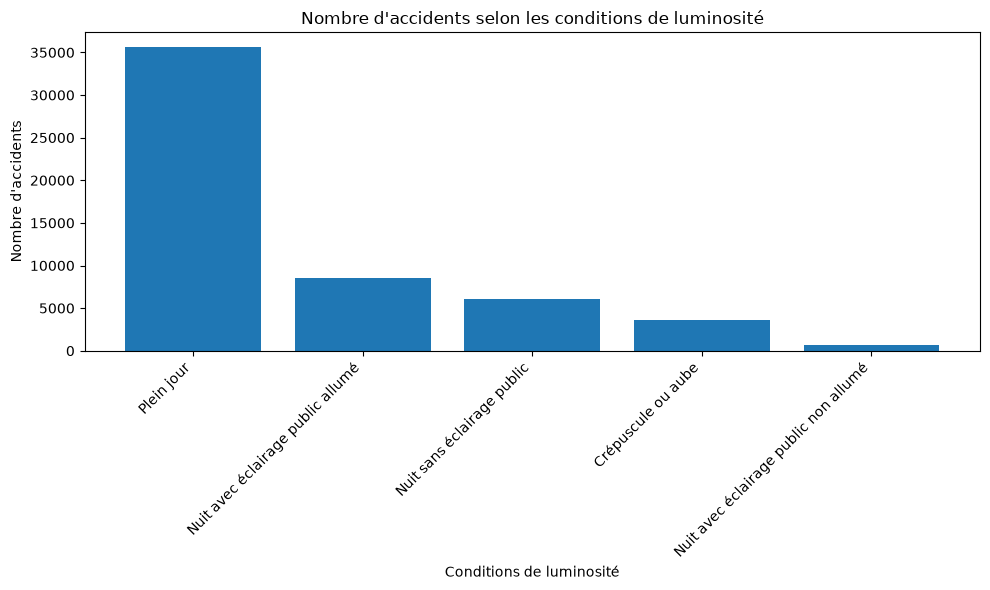

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    accidents_par_luminosite.index,
    accidents_par_luminosite.values
)

plt.xlabel("Conditions de luminosité")
plt.ylabel("Nombre d'accidents")
plt.title("Nombre d'accidents selon les conditions de luminosité")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Interprétation

La majorité des accidents recensés en 2024 ont eu lieu en plein jour, avec 35 580 accidents. Les accidents survenus de nuit représentent néanmoins une part importante des accidents, notamment lorsque l'éclairage public est allumé.

La catégorie « Nuit avec éclairage public non allumé » est celle qui compte le moins d'accidents, avec 623 cas.

## Accidents selon les conditions atmosphériques

Nous analysons maintenant la répartition des accidents selon les conditions atmosphériques au moment de l'accident.

In [8]:
# Nombre d'accidents selon les conditions atmosphériques

accidents_par_atmosphere = (
    accidents["atm_label"]
    .value_counts()
)

print(accidents_par_atmosphere)

atm_label
Normale                 41802
Pluie légère             6779
Temps couvert            2374
Pluie forte              1449
Temps éblouissant         817
Brouillard ou fumée       529
Autre                     250
Neige ou grêle            233
Vent fort ou tempête      169
Name: count, dtype: int64


### Visualisation

Le graphique suivant permet de comparer le nombre d'accidents selon les différentes conditions atmosphériques.

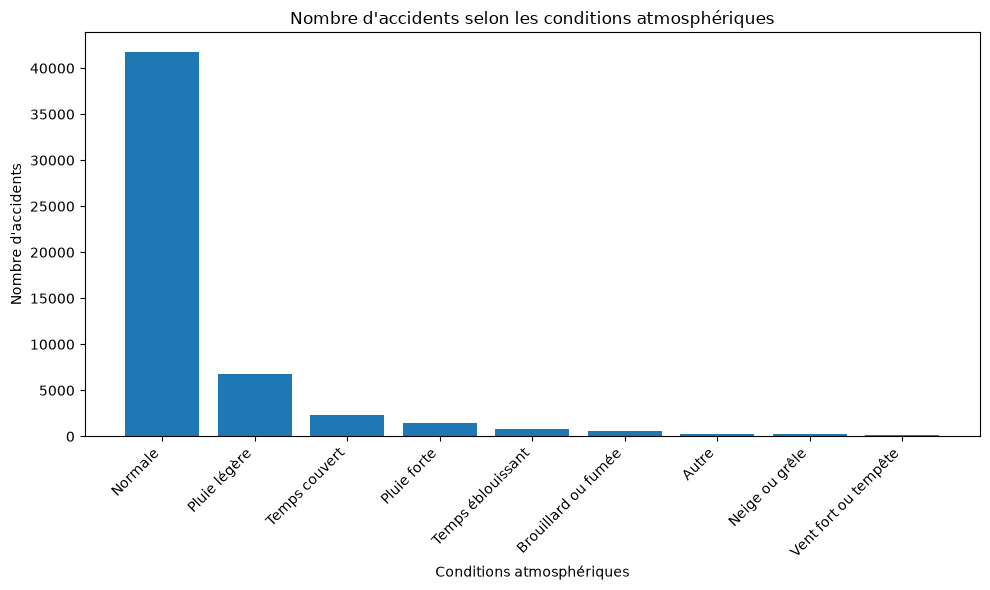

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(
    accidents_par_atmosphere.index,
    accidents_par_atmosphere.values
)

plt.xlabel("Conditions atmosphériques")
plt.ylabel("Nombre d'accidents")
plt.title("Nombre d'accidents selon les conditions atmosphériques")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Interprétation

La majorité des accidents recensés en 2024 ont eu lieu dans des conditions atmosphériques normales, avec 41 802 accidents.

Les accidents survenus sous la pluie représentent également une part importante des accidents, avec 6 779 accidents en cas de pluie légère et 1 449 en cas de pluie forte.

Cependant, ces résultats doivent être interprétés avec prudence : les conditions météorologiques normales sont également probablement les plus fréquentes. Le nombre brut d'accidents ne permet donc pas, à lui seul, de déterminer quelles conditions météorologiques sont les plus dangereuses.

## Accidents en et hors agglomération

Nous analysons maintenant la répartition des accidents selon qu'ils se sont produits en agglomération ou hors agglomération.

In [10]:
# Nombre d'accidents en et hors agglomération

accidents_par_agglomeration = (
    accidents["agg_label"]
    .value_counts()
)

print(accidents_par_agglomeration)

agg_label
En agglomération      34010
Hors agglomération    20392
Name: count, dtype: int64


### Visualisation

Le graphique suivant permet de comparer le nombre d'accidents survenus en et hors agglomération.

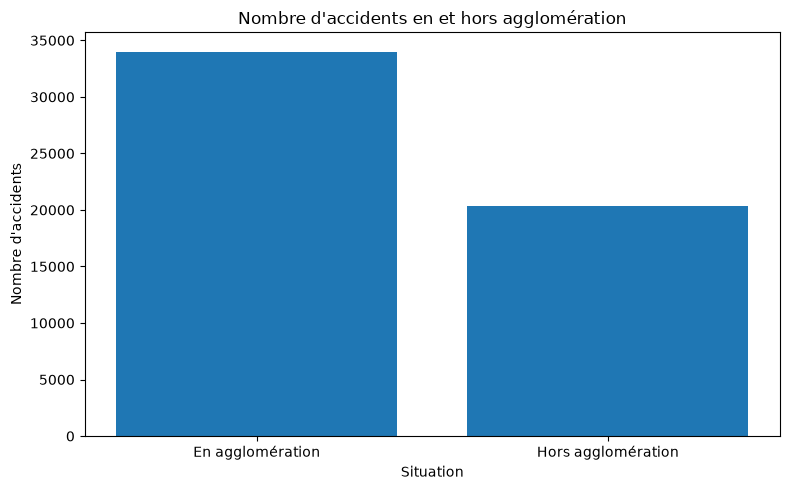

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    accidents_par_agglomeration.index,
    accidents_par_agglomeration.values
)

plt.xlabel("Situation")
plt.ylabel("Nombre d'accidents")
plt.title("Nombre d'accidents en et hors agglomération")

plt.tight_layout()

plt.show()

### Interprétation

La majorité des accidents recensés en 2024 ont eu lieu en agglomération, avec 34 010 accidents, contre 20 392 hors agglomération.

Cela peut notamment s'expliquer par une circulation plus importante et une plus forte concentration d'usagers dans les zones urbaines. Cependant, le nombre brut d'accidents ne permet pas à lui seul de déterminer si la circulation en agglomération est plus dangereuse.

## Accidents selon la catégorie de route

Nous analysons maintenant la répartition des accidents selon le type de route sur lequel ils se sont produits.

In [12]:
# Nombre d'accidents selon la catégorie de route

accidents_par_route = (
    accidents["catr_label"]
    .value_counts()
)

print(accidents_par_route)

catr_label
Voie communale                                            22910
Route départementale                                      20658
Autoroute                                                  5092
Route nationale                                            3531
Routes de métropole urbaine                                1500
Parc de stationnement ouvert à la circulation publique      439
Autre                                                       216
Hors réseau public                                           56
Name: count, dtype: int64


### Visualisation

Le graphique suivant permet de comparer le nombre d'accidents selon les différentes catégories de routes.

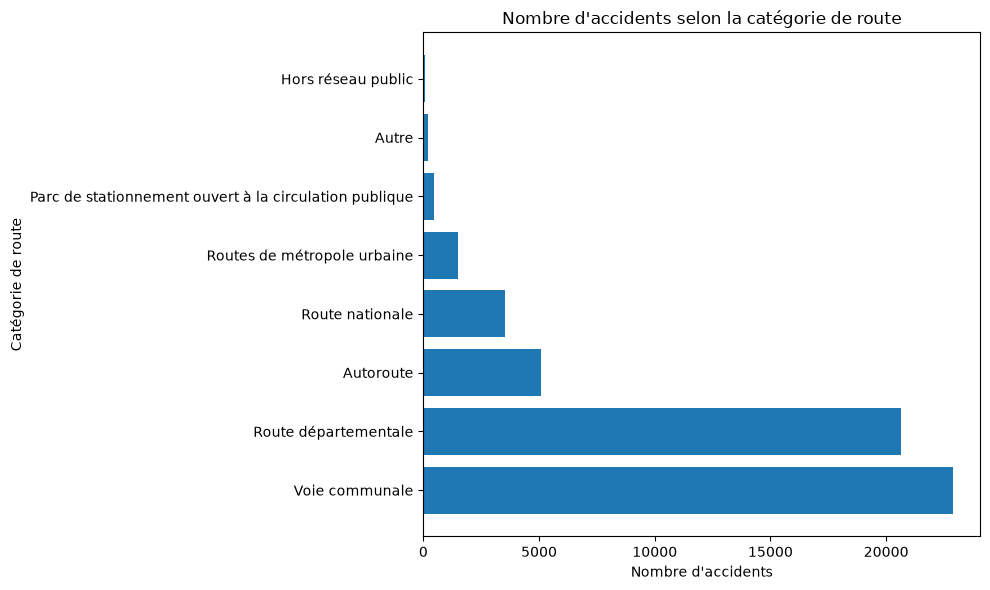

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(
    accidents_par_route.index,
    accidents_par_route.values
)

plt.xlabel("Nombre d'accidents")
plt.ylabel("Catégorie de route")
plt.title("Nombre d'accidents selon la catégorie de route")

plt.tight_layout()

plt.show()

### Interprétation

Les accidents recensés en 2024 se concentrent principalement sur les voies communales, avec 22 910 accidents, et sur les routes départementales, avec 20 658 accidents.

Les autoroutes et les routes nationales comptent également plusieurs milliers d'accidents, mais dans des proportions plus faibles.

Cependant, ces résultats doivent être interprétés avec prudence, car le nombre d'accidents dépend également de facteurs comme la longueur du réseau routier, le volume de circulation et la fréquentation de chaque type de route.

## Répartition des niveaux de gravité

Nous analysons maintenant la répartition des différents niveaux de gravité des usagers impliqués dans les accidents.

In [14]:
# Nombre d'usagers selon le niveau de gravité

usagers_par_gravite = (
    usagers["grav_label"]
    .value_counts()
)

print(usagers_par_gravite)

grav_label
Indemne               52920
Blessé léger          49709
Blessé hospitalisé    19126
Tué                    3432
Name: count, dtype: int64


### Visualisation

Le graphique suivant permet de comparer la répartition des usagers selon leur niveau de gravité.

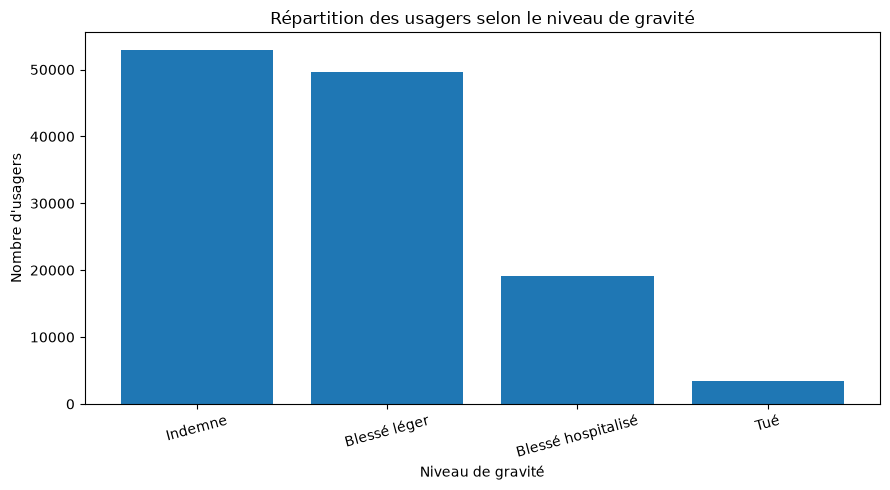

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    usagers_par_gravite.index,
    usagers_par_gravite.values
)

plt.xlabel("Niveau de gravité")
plt.ylabel("Nombre d'usagers")
plt.title("Répartition des usagers selon le niveau de gravité")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

### Interprétation

La majorité des usagers impliqués dans les accidents sont indemnes ou légèrement blessés. On compte respectivement 52 920 usagers indemnes et 49 709 blessés légers.

Les accidents ont également entraîné 19 126 blessés hospitalisés et 3 432 décès.

Ces résultats montrent que les conséquences des accidents peuvent varier fortement selon les usagers impliqués.

## Répartition de l'âge des usagers

Nous analysons maintenant la répartition de l'âge des usagers impliqués dans les accidents.

In [16]:
# Statistiques descriptives sur l'âge

print(usagers["age"].describe())

count    122608.000000
mean         38.924589
std          19.327486
min           0.000000
25%          23.000000
50%          36.000000
75%          53.000000
max         110.000000
Name: age, dtype: float64


### Visualisation

Le graphique suivant permet de visualiser la répartition des âges des usagers impliqués dans les accidents.

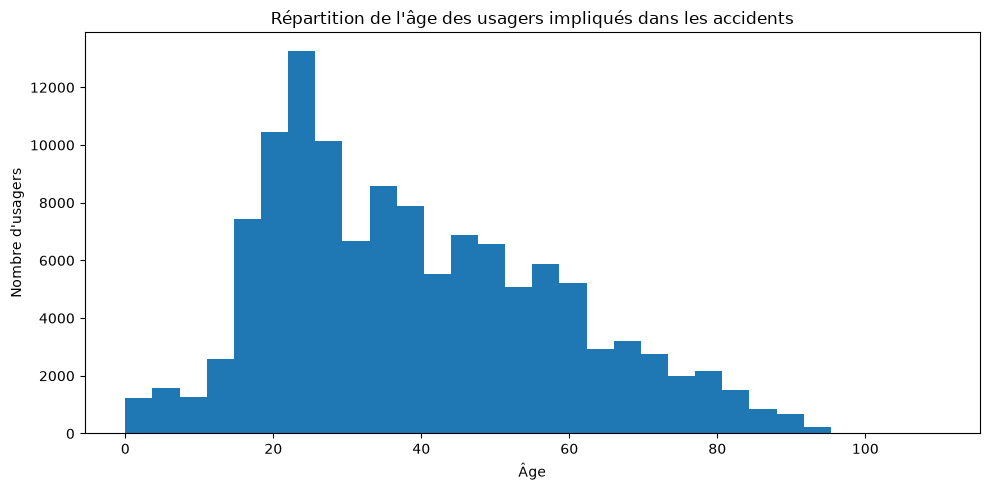

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    usagers["age"].dropna(),
    bins=30
)

plt.xlabel("Âge")
plt.ylabel("Nombre d'usagers")
plt.title("Répartition de l'âge des usagers impliqués dans les accidents")

plt.tight_layout()

plt.show()

### Interprétation

La répartition des âges montre un pic autour de 25 ans, ce qui indique qu'une proportion importante des usagers impliqués dans les accidents sont de jeunes adultes.

L'âge moyen des usagers est d'environ 39 ans, tandis que l'âge médian est de 36 ans. La moitié des usagers dont l'âge est renseigné ont entre 23 et 53 ans.

Après le pic observé chez les jeunes adultes, le nombre d'usagers impliqués dans les accidents tend globalement à diminuer avec l'âge.

## Gravité selon l'âge et le sexe des usagers

Nous analysons la répartition des niveaux de gravité selon l'âge et le sexe des usagers impliqués dans les accidents.

Pour faciliter cette analyse, les âges sont regroupés en différentes tranches d'âge.

In [18]:
# Création des tranches d'âge

bins = [0, 18, 25, 40, 60, 120]

labels = [
    "0-17 ans",
    "18-24 ans",
    "25-39 ans",
    "40-59 ans",
    "60 ans et plus"
]

usagers["tranche_age"] = pd.cut(
    usagers["age"],
    bins=bins,
    labels=labels,
    right=False
)

In [19]:
# Tableau croisé entre l'âge, le sexe et la gravité

tableau_gravite = pd.crosstab(
    [usagers["tranche_age"], usagers["sexe_label"]],
    usagers["grav_label"]
)

print(tableau_gravite)

grav_label                    Blessé hospitalisé  Blessé léger  Indemne  Tué
tranche_age    sexe_label                                                   
0-17 ans       Féminin                       597          2350     1340   36
               Masculin                     1472          3828     1729   95
18-24 ans      Féminin                       909          3614     2434   94
               Masculin                     2852          6582     6403  473
               Non renseigné                   0             0        5    0
25-39 ans      Féminin                       998          4974     4122  123
               Masculin                     3398          9416    10846  623
40-59 ans      Féminin                      1204          4485     3954  142
               Masculin                     3477          7892    11297  707
60 ans et plus Féminin                      1730          2900     2531  374
               Masculin                     2488          3662     5687  765

### Visualisation

Le graphique suivant permet de comparer la répartition des niveaux de gravité selon les tranches d'âge et le sexe des usagers.

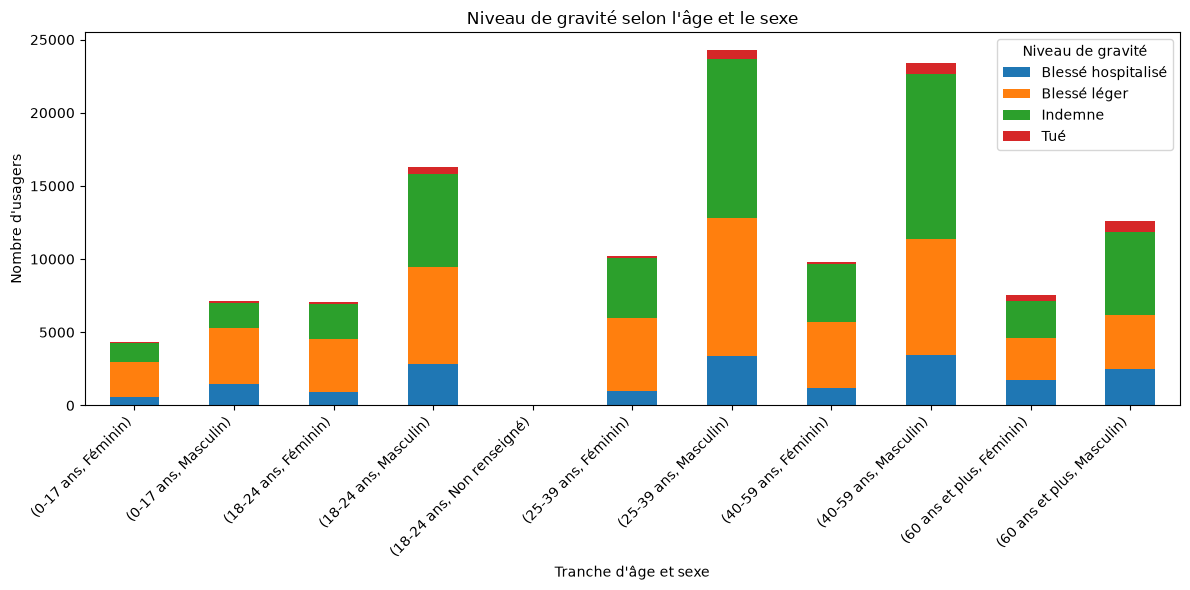

In [20]:
# Visualisation de la gravité selon l'âge et le sexe

tableau_gravite.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Tranche d'âge et sexe")
plt.ylabel("Nombre d'usagers")
plt.title("Niveau de gravité selon l'âge et le sexe")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Niveau de gravité")

plt.tight_layout()

plt.show()

### Interprétation

Le graphique montre que les hommes sont plus nombreux que les femmes parmi les usagers impliqués dans les accidents dans la majorité des tranches d'âge.

Les tranches d'âge de 25 à 39 ans et de 40 à 59 ans regroupent le plus grand nombre d'usagers impliqués dans les accidents.

Cependant, les effectifs étant différents selon les groupes, les nombres bruts ne permettent pas de comparer directement la gravité des accidents entre les différentes catégories. Une analyse en pourcentage permettrait une comparaison plus pertinente.

## Répartition selon la catégorie d'usager

Nous analysons la répartition des usagers selon leur catégorie : conducteur, passager ou piéton.

In [21]:
# Nombre d'usagers selon leur catégorie

usagers_par_categorie = (
    usagers["catu_label"]
    .value_counts()
)

print(usagers_par_categorie)

catu_label
Conducteur    92581
Passager      23205
Piéton         9401
Name: count, dtype: int64


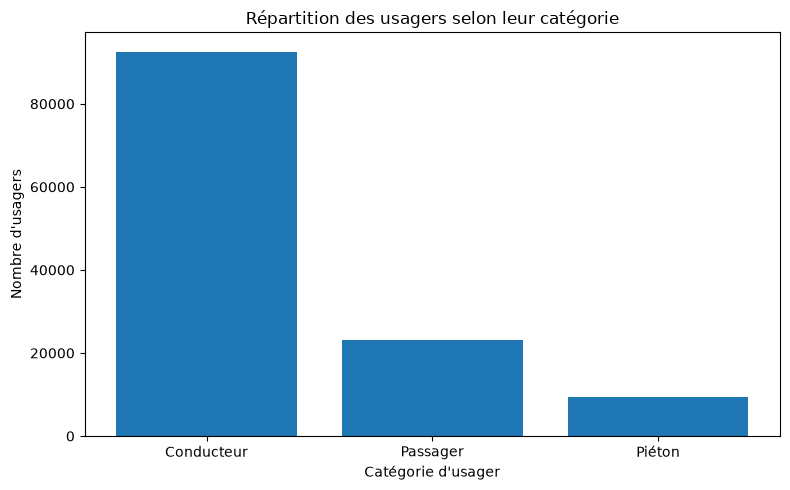

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    usagers_par_categorie.index,
    usagers_par_categorie.values
)

plt.xlabel("Catégorie d'usager")
plt.ylabel("Nombre d'usagers")
plt.title("Répartition des usagers selon leur catégorie")

plt.tight_layout()

plt.show()

### Interprétation

La majorité des usagers impliqués dans les accidents sont des conducteurs, avec 92 581 personnes. Les passagers et les piétons représentent une proportion plus faible des usagers impliqués.

# Conclusion générale

Cette analyse exploratoire des accidents de la route en France en 2024 a permis d'identifier plusieurs tendances dans les données.

Les accidents recensés sont principalement survenus en agglomération, sur les voies communales et les routes départementales. La majorité ont également eu lieu en plein jour et dans des conditions atmosphériques normales. Ces résultats doivent cependant être interprétés avec prudence, car ils ne prennent pas en compte des facteurs tels que le volume de circulation ou la fréquence réelle de chaque situation.

Concernant les usagers, les conducteurs représentent la majorité des personnes impliquées dans les accidents. La répartition des âges présente un pic autour de 25 ans, et l'analyse de la gravité montre que les conséquences des accidents varient selon les caractéristiques des usagers.

Cette analyse a également permis de préparer et de mieux comprendre les données. Elle constitue ainsi une première étape avant la mise en place d'analyses plus avancées, notamment l'utilisation de techniques de Machine Learning pour étudier la gravité des accidents à partir des différentes variables disponibles.